In [83]:
import json
import powerlaw
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
from os.path import expanduser
import pandas as pd
from pyvis import network as net
import pylab as pl
from collections import Counter
import matplotlib.ticker as ticker
from matplotlib.patches import Patch
import textwrap
from adjustText import adjust_text
import string

# Accessible Network

28


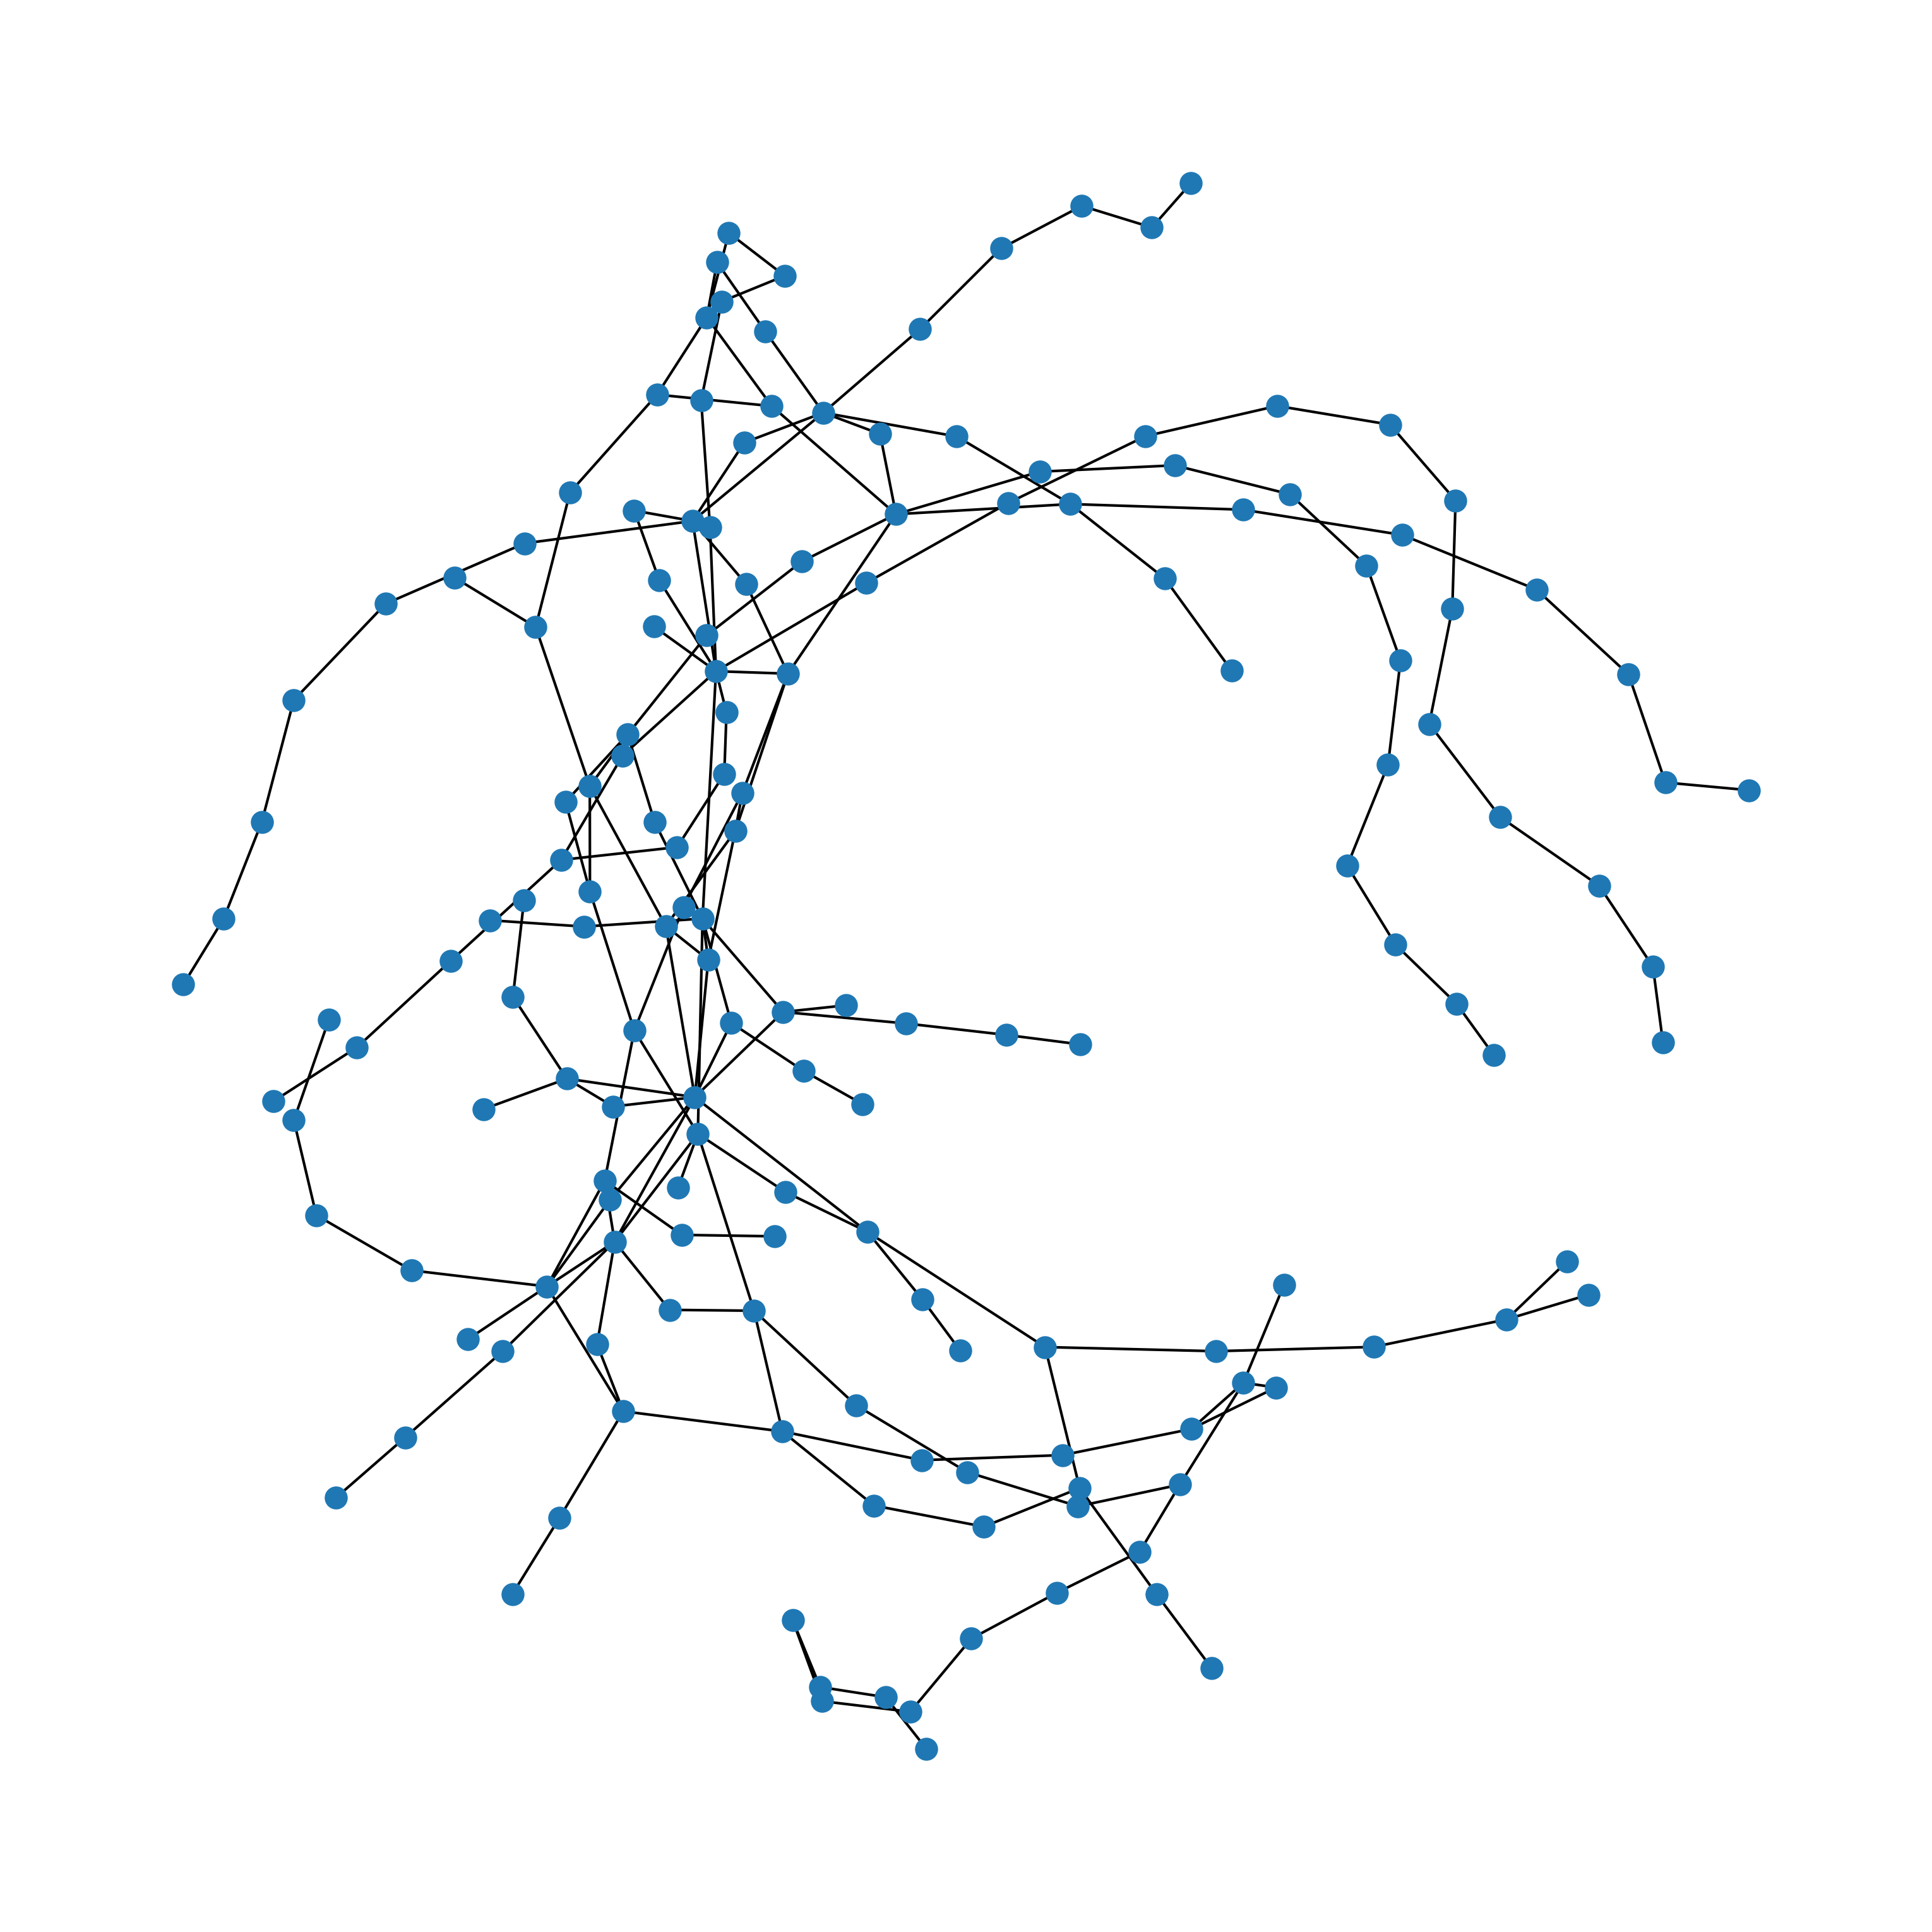

In [2]:
# Data is imported from the csv file, path needs to be accurate to current path user is trying to access
GL=nx.read_adjlist(expanduser("~/Documents/Miktek Files/Betz Inaccesiblity Paper/London Accessible Network/London_Accessible_Network.csv"),delimiter=',')
N = len(GL.nodes)
M = len(GL.edges)

print(nx.diameter(GL))

#Graph of the London Accessible Network
pos=nx.spring_layout(GL,k=2, iterations=1000)
plt.figure(5,figsize=(10,10),dpi=300) 
nx.draw(GL, pos ,node_size=60,font_size=10)
plt.savefig('LondonACCGraph.png', bbox_inches='tight', dpi=300)

In [3]:
#Degree for the London Accessible
Degl = [val for (node, val) in GL.degree()]

In [4]:
#Betweenness Centrality Calculation
Bel = nx.betweenness_centrality(GL)
Belarr=np.array(list(Bel.values()))

print("Top 10 Betweenness Centrality Nodes")
sorted(Bel.items(), reverse= True, key=lambda x: x[1])[:10]

Top 10 Betweenness Centrality Nodes


[('Stratford', 0.48767577523560385),
 ('Tottenham Court Road', 0.4151507747874665),
 ('Bond Street', 0.3213712593581061),
 ('Canary Wharf', 0.2558386854285649),
 ('Whitechapel', 0.23565257754059374),
 ('Ealing Broadway', 0.21998988112524814),
 ("King's Cross St. Pancras", 0.21393713913557727),
 ('West Ham', 0.1679622409164335),
 ('Paddington', 0.1373168811458912),
 ('West Ealing', 0.13720114857537213)]

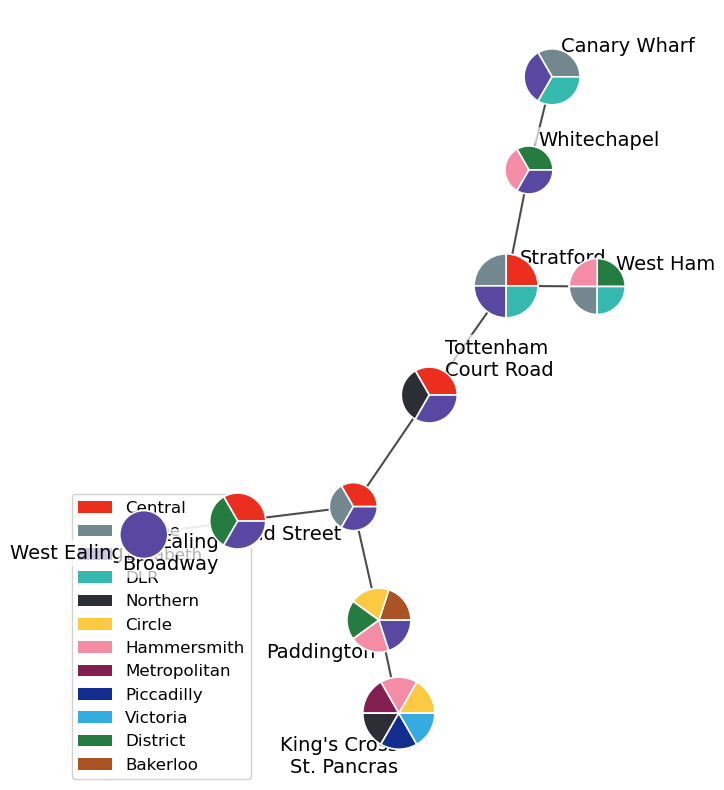

In [5]:
#Top Ten Betweenness Subgraph
HLB = GL.subgraph([node for node, _ in sorted(Bel.items(), key=lambda x: x[1], reverse=True)[:10]])
posb = nx.spring_layout(HLB, seed=42)
HLB = nx.relabel_nodes(HLB, {n: n.strip('\ufeff').strip() for n in HLB.nodes()})

node_configb = {
    "Stratford": {"slices": [1,1,1, 1],    "colors": ['#ec2e1e', '#72888e','#5848a2','#35b9ae'], "size": 0.08, "legend": ["Central", "Jubilee", "Elizabeth", "DLR"]},
    "Tottenham Court Road": {"slices": [1,1,1],    "colors": ['#ec2e1e','#2c2e35','#5848a2'], "size": 0.07, "legend": ["Central","Northern","Elizabeth"]},
    "King's Cross St. Pancras": {"slices": [1,1,1,1, 1, 1], "colors": ["#fcc942", '#F38CA4','#831e53', '#2c2e35','#132d8e','#35acdf'], "size": 0.09,"legend": ["Circle", "Hammersmith", "Metropolitan", "Northern", "Piccadilly" ,"Victoria"]},
    "Canary Wharf": {"slices": [1, 1,1],    "colors": ['#72888e','#5848a2','#35b9ae'], "size": 0.07,"legend": ["Jubilee","Elizabeth", "DLR"]},
    "Whitechapel": {"slices": [1, 1, 1], "colors": ['#257c40','#F38CA4','#5848a2'], "size": 0.06,"legend": ["District","Hammersmith","Elizabeth"]},
    "Bond Street": {"slices": [1, 1,1],    "colors": ['#ec2e1e','#72888e','#5848a2'], "size": 0.06, "legend": ["Central", "Jubilee", "Elizabeth"]},
    "Ealing Broadway": {"slices": [1,1,1],    "colors": ['#ec2e1e','#257c40','#5848a2'], "size": 0.07,"legend": ["Central", "District", "Elizabeth"]},
    "West Ham": {"slices": [1,1,1,1], "colors": ['#257c40','#F38CA4','#72888e','#35b9ae'], "size": 0.07,"legend": ["District", "Hammersmith","Jubilee","DLR"]},
    "Paddington": {"slices": [1,1,1,1,1], "colors": ['#ac5326','#fcc942','#257c40','#F38CA4','#5848a2'], "size": 0.08,"legend": ["Bakerloo","Circle","District","Hammersmith", "Elizabeth"]},
    "West Ealing": {"slices": [1],    "colors": ["#5848a2"], "size": 0.06,"legend": ["Elizabeth"]}
}

#Bakerloo '#ac5326'
#Central '#ec2e1e'
#Circle '#fcc942'
#District '#257c40'
#Hammersmith '#F38CA4'
#Jubilee '#72888e'
#Metro '#831e53'
#Northern '#2c2e35'
#Piccadilly '#132d8e'
#Victoria '#35acdf'
#Elizabeth '#5848a2'
#DLR '#35b9ae'

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_aspect("equal")
ax.axis("off")

nx.draw_networkx_edges(HLB, posb, ax=ax, edge_color="#000000", width=1.5, alpha=0.7)

# Force layout to initialise before transforms are used
fig.canvas.draw()

for node, (x, y) in posb.items():
    cfg  = node_configb[node]
    size = cfg["size"]

    x_fig, y_fig = ax.transData.transform((x, y))
    x_fig, y_fig = fig.transFigure.inverted().transform((x_fig, y_fig))

    pie_ax = fig.add_axes([x_fig - size / 2, y_fig - size / 2, size, size])
    pie_ax.pie(cfg["slices"], colors=cfg["colors"],
               wedgeprops=dict(linewidth=1.2, edgecolor="white"))
    pie_ax.set_aspect("equal")

cx = np.mean([x for x, y in posb.values()])
cy = np.mean([y for x, y in posb.values()])

for node, (x, y) in posb.items():
    cfg = node_configb[node]
    angle = np.arctan2(y - cy, x - cx)
    offset = cfg["size"] * 0.1 + 0.06

    lx = x + np.cos(angle) * offset
    ly = y + np.sin(angle) * offset

    ha = "left" if np.cos(angle) > 0 else "right"
    va = "bottom" if np.sin(angle) > 0 else "top"

    label = textwrap.fill(node, width=14)   # wrap at 14 characters

    ax.text(lx, ly, label, ha=ha, va=va,
            fontsize=14, fontweight="medium", color="#000000", zorder=10,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

seen = {}
for cfg in node_configb.values():
    for color, label in zip(cfg["colors"], cfg["legend"]):
        if label not in seen:
            seen[label] = color

handles = [Patch(facecolor=color, label=label) for label, color in seen.items()]

ax.legend(
    handles=handles,
    loc="lower left",
    fontsize=12,
    bbox_to_anchor=(-.06, -.01),
    title_fontsize=9,
    framealpha=0.9,
    edgecolor="#cccccc"
)

plt.show()

In [6]:
#Closeness Centrality Calculation
Cel = nx.closeness_centrality(GL)
Celarr=np.array(list(Cel.values()))

print("Top 10 Closeness Centrality Nodes")
sorted(Cel.items(), reverse= True, key=lambda x: x[1])[:10]

Top 10 Closeness Centrality Nodes


[('Tottenham Court Road', 0.19876543209876543),
 ('Stratford', 0.1961023142509135),
 ('Bond Street', 0.19143876337693222),
 ('Farringdon', 0.1852704257767549),
 ('Whitechapel', 0.18253968253968253),
 ('Finchley Central', 0.17888888888888888),
 ("King's Cross St. Pancras", 0.17849223946784923),
 ('Golders Green', 0.17809734513274336),
 ('Liverpool Street', 0.17653508771929824),
 ('Paddington', 0.17424242424242425)]

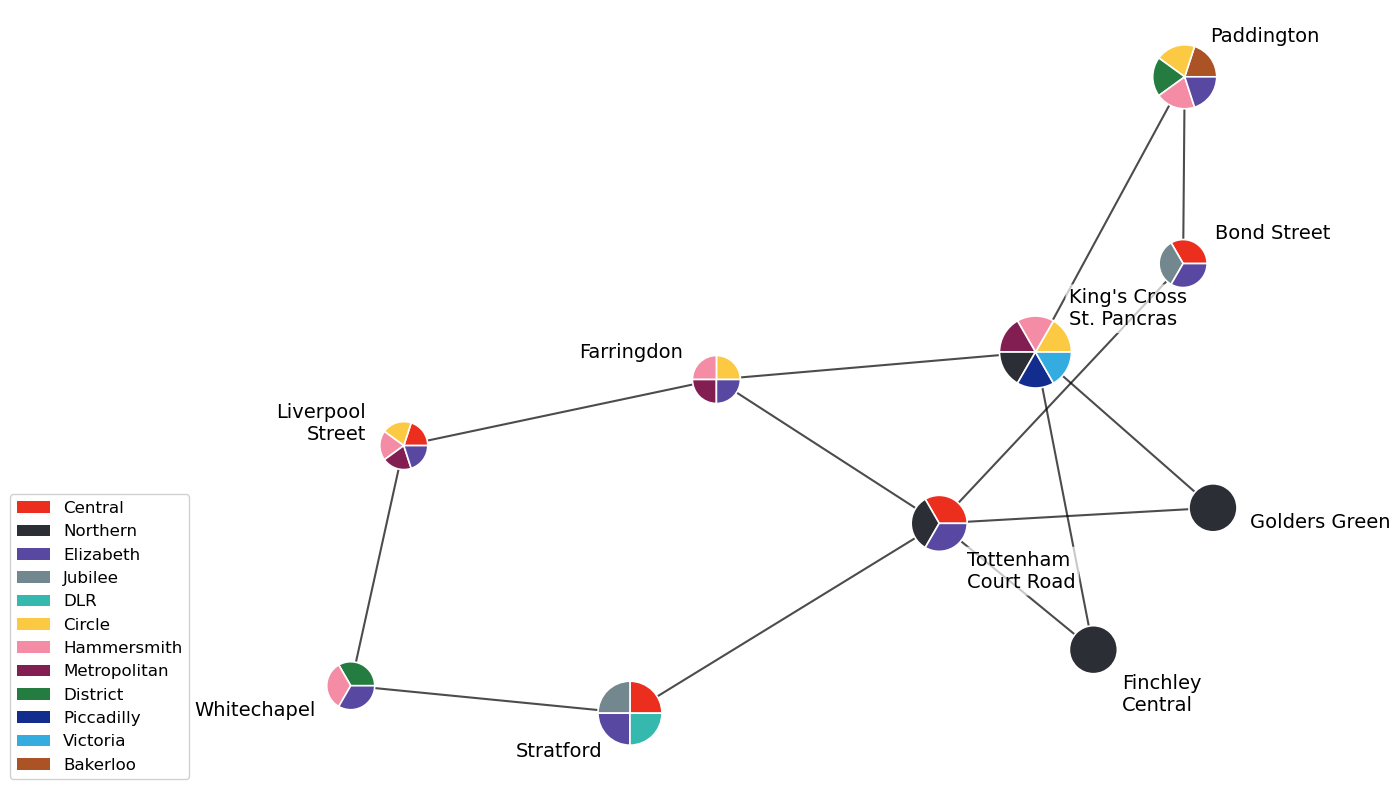

In [7]:
#Top Ten Closeness Subgraph
HLC=GL.subgraph([node for node, _ in sorted(Cel.items(), key=lambda x: x[1], reverse=True)[:10]])
posc = nx.spring_layout(HLC, seed=49)
HLC = nx.relabel_nodes(HLC, {n: n.strip('\ufeff').strip() for n in HLC.nodes()})

node_configc = {
    "Tottenham Court Road": {"slices": [1,1,1],    "colors": ['#ec2e1e','#2c2e35','#5848a2'], "size": 0.07, "legend": ["Central","Northern","Elizabeth"]},
    "Stratford":            {"slices": [1,1,1,1],  "colors": ['#ec2e1e','#72888e','#5848a2','#35b9ae'], "size": 0.08, "legend": ["Central","Jubilee","Elizabeth","DLR"]},
    "Bond Street":          {"slices": [1,1,1],    "colors": ['#ec2e1e','#72888e','#5848a2'], "size": 0.06, "legend": ["Central","Jubilee","Elizabeth"]},
    "Farringdon":           {"slices": [1,1,1,1],  "colors": ['#fcc942','#F38CA4','#831e53','#5848a2'], "size": 0.06, "legend": ["Circle","Hammersmith","Metropolitan","Elizabeth"]},
    "Whitechapel":          {"slices": [1,1,1],    "colors": ['#257c40','#F38CA4','#5848a2'], "size": 0.06, "legend": ["District","Hammersmith","Elizabeth"]},
    "Finchley Central":     {"slices": [1],        "colors": ['#2c2e35'], "size": 0.06, "legend": ["Northern"]},
    "King's Cross St. Pancras": {"slices": [1,1,1,1,1,1], "colors": ["#fcc942",'#F38CA4','#831e53','#2c2e35','#132d8e','#35acdf'], "size": 0.09, "legend": ["Circle","Hammersmith","Metropolitan","Northern","Piccadilly","Victoria"]},
    "Golders Green":        {"slices": [1],        "colors": ['#2c2e35'], "size": 0.06, "legend": ["Northern"]},
    "Liverpool Street":     {"slices": [1,1,1,1,1], "colors": ['#ec2e1e','#fcc942', '#F38CA4','#831e53','#5848a2'], "size": 0.06,"legend": ["Central","Circle","Hammersmith","Metropolitan","Elizabeth"]},
    "Paddington":           {"slices": [1,1,1,1,1], "colors": ['#ac5326','#fcc942','#257c40','#F38CA4','#5848a2'], "size": 0.08, "legend": ["Bakerloo","Circle","District","Hammersmith","Elizabeth"]},
}

#Bakerloo '#ac5326'
#Central '#ec2e1e'
#Circle '#fcc942'
#District '#257c40'
#Hammersmith '#F38CA4'
#Jubilee '#72888e'
#Metro '#831e53'
#Northern '#2c2e35'
#Piccadilly '#132d8e'
#Victoria '#35acdf'
#Elizabeth '#5848a2'
#DLR '#35b9ae'

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_aspect("equal")
ax.axis("off")

nx.draw_networkx_edges(HLC, posc, ax=ax, edge_color="#000000", width=1.5, alpha=0.7)

# Force layout to initialise before transforms are used
fig.canvas.draw()

for node, (x, y) in posc.items():
    cfg  = node_configc[node]
    size = cfg["size"]

    x_fig, y_fig = ax.transData.transform((x, y))
    x_fig, y_fig = fig.transFigure.inverted().transform((x_fig, y_fig))

    pie_ax = fig.add_axes([x_fig - size / 2, y_fig - size / 2, size, size])
    pie_ax.pie(cfg["slices"], colors=cfg["colors"],
               wedgeprops=dict(linewidth=1.2, edgecolor="white"))
    pie_ax.set_aspect("equal")

cx = np.mean([x for x, y in posc.values()])
cy = np.mean([y for x, y in posc.values()])

for node, (x, y) in posc.items():
    cfg = node_configc[node]
    angle = np.arctan2(y - cy, x - cx)
    offset = cfg["size"] * 0.2 + 0.06

    lx = x + np.cos(angle) * offset
    ly = y + np.sin(angle) * offset

    ha = "left" if np.cos(angle) > 0 else "right"
    va = "bottom" if np.sin(angle) > 0 else "top"

    label = textwrap.fill(node, width=14)   # wrap at 14 characters

    ax.text(lx, ly, label, ha=ha, va=va,
            fontsize=14, fontweight="medium", color="#000000", zorder=10,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

seen = {}
for cfg in node_configc.values():
    for color, label in zip(cfg["colors"], cfg["legend"]):
        if label not in seen:
            seen[label] = color

handles = [Patch(facecolor=color, label=label) for label, color in seen.items()]

ax.legend(
    handles=handles,
    loc="lower right",
    fontsize=12,
    bbox_to_anchor=(-.06, -.01),
    title_fontsize=9,
    framealpha=0.9,
    edgecolor="#cccccc"
)

plt.show()

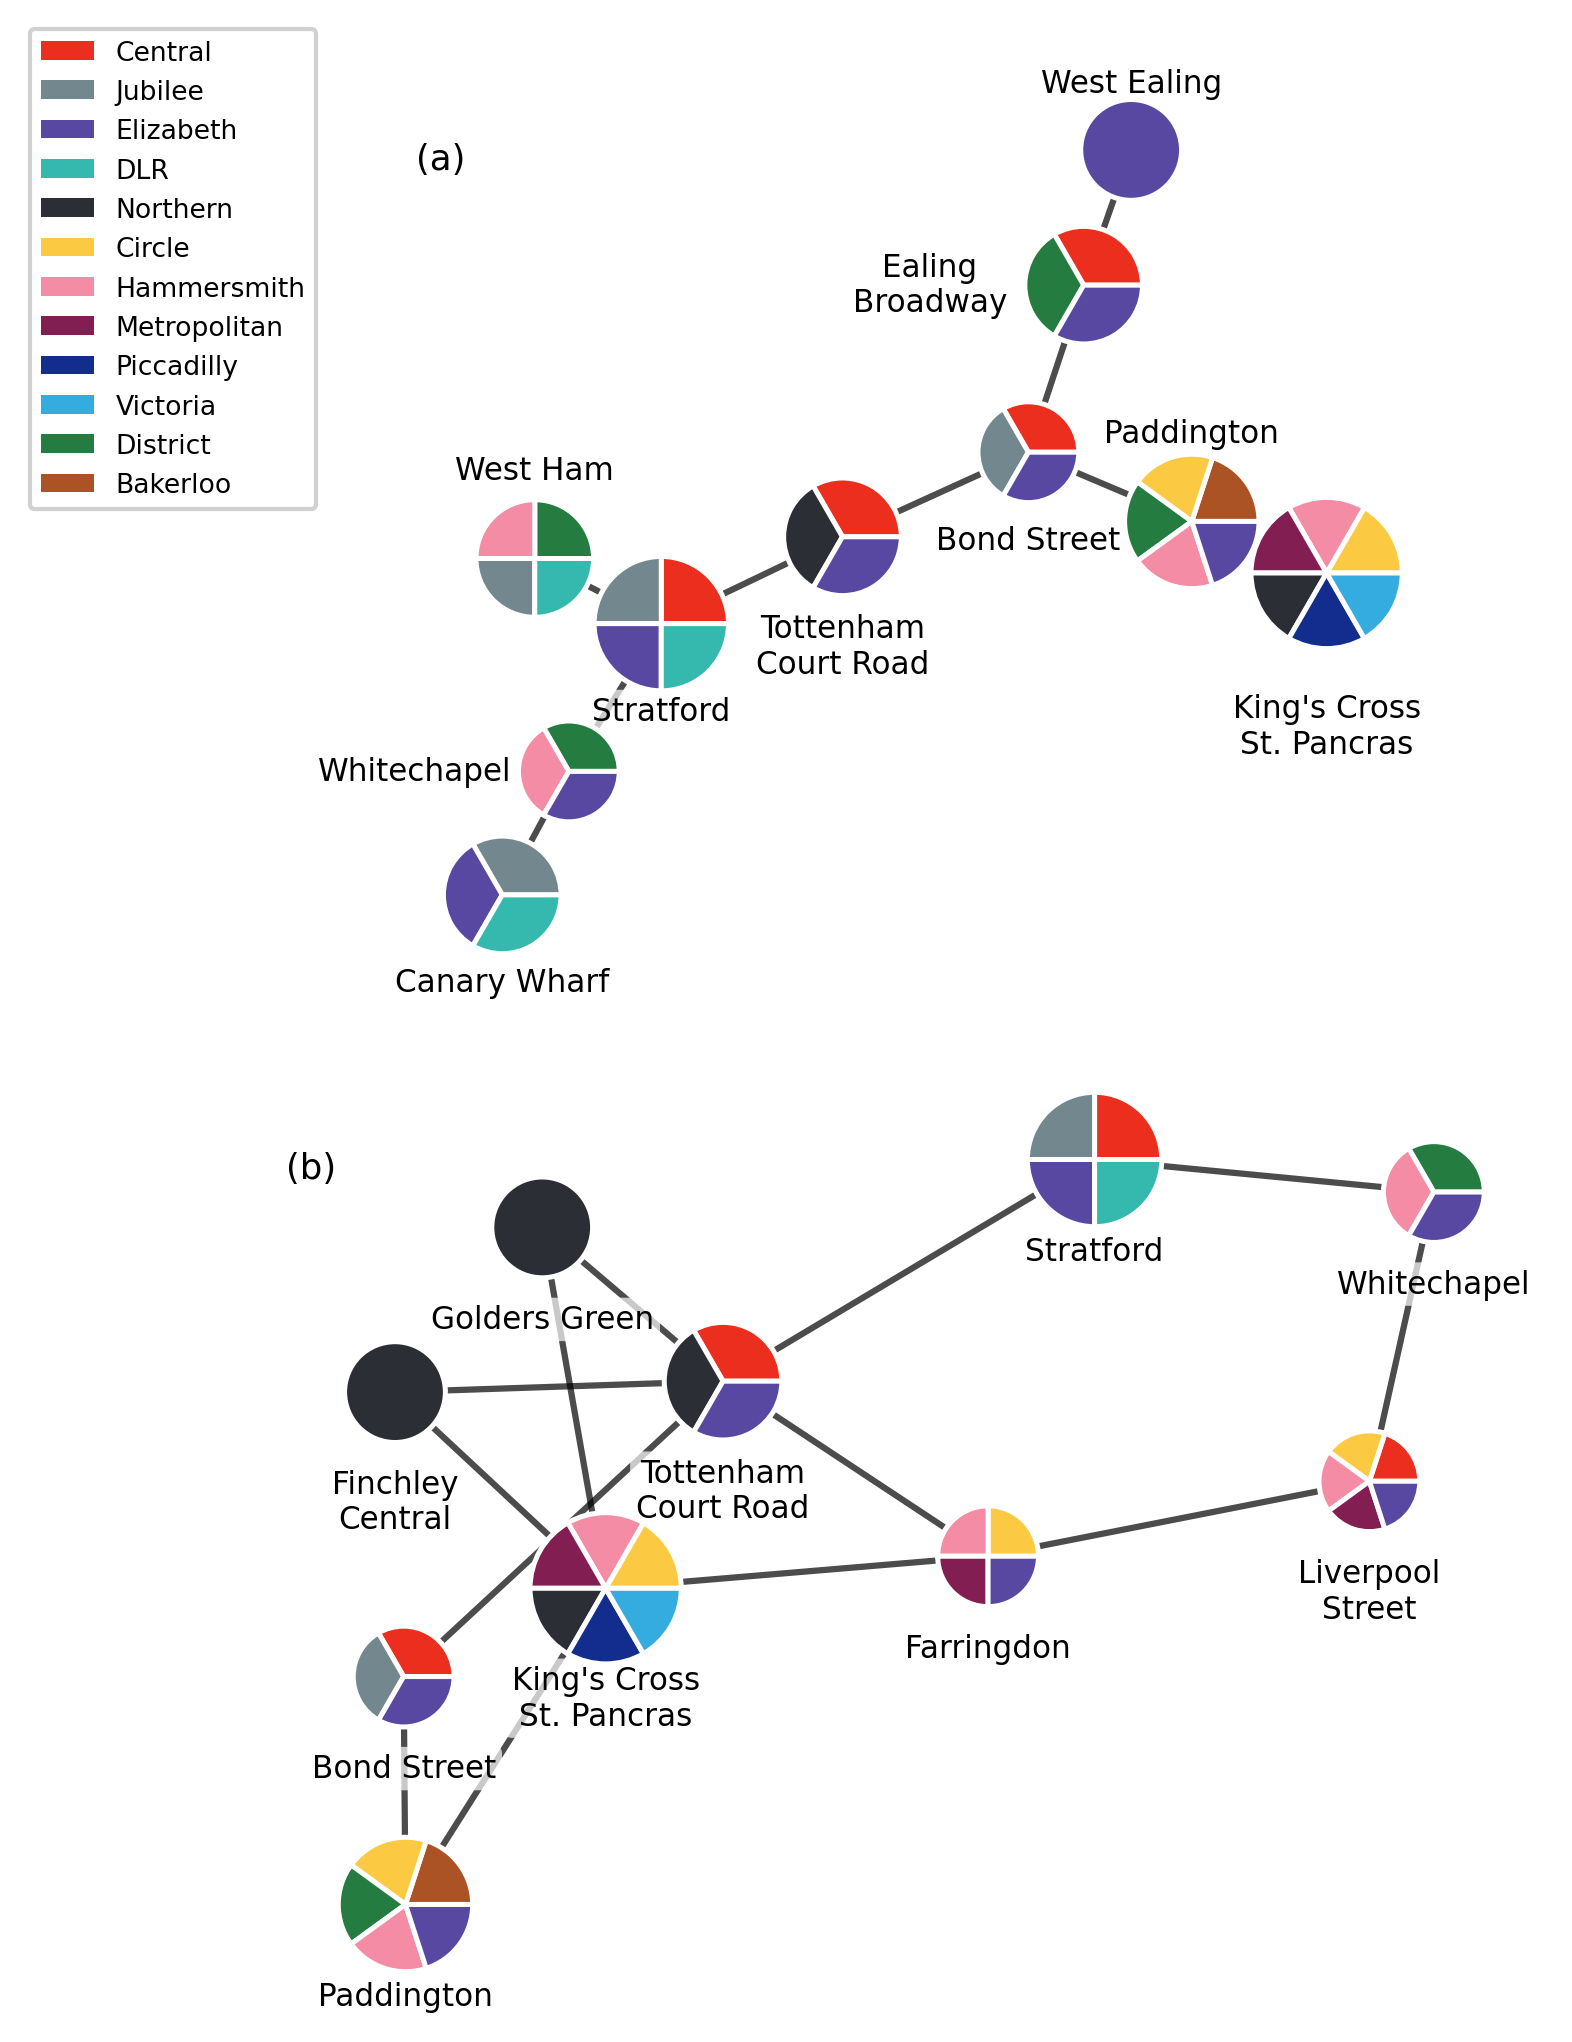

In [43]:
fig = plt.figure(figsize=(8,7), dpi=300)
scale = fig.get_size_inches()[0] / 15
fig.subplots_adjust(left=0.06, right=0.80, top=0.97, bottom=0.06, hspace=0.12)
posb = nx.spring_layout(HLB, seed=70, k=.32)
posc = nx.spring_layout(HLC, seed=42, k=.32)

# ── (a) Betweenness ──────────────────────────────────────────────────────────
ax1 = fig.add_subplot(2, 1, 1)
ax1.set_aspect("equal")
ax1.axis("off")
ax1.set_title("(a)", fontsize=16*scale, fontweight="medium", y=.8, pad=20, loc="left")
nx.draw_networkx_edges(HLB, posb, ax=ax1, edge_color="#000000", width=1.5, alpha=0.7)

ax2 = fig.add_subplot(2, 1, 2)
ax2.set_aspect("equal")
ax2.axis("off")
ax2.set_title("(b)", fontsize=16*scale, fontweight="medium", y=.8, pad=20, loc="left")

nx.draw_networkx_edges(HLC, posc, ax=ax2, edge_color="#000000", width=1.5, alpha=0.7)

fig.canvas.draw()

for node, (x, y) in posb.items():
    cfg = node_configb[node]
    size = cfg["size"]
    x_fig, y_fig = ax1.transData.transform((x, y))
    x_fig, y_fig = fig.transFigure.inverted().transform((x_fig, y_fig))
    pie_ax = fig.add_axes([x_fig - size/2, y_fig - size/2, size, size])
    pie_ax.pie(cfg["slices"], colors=cfg["colors"], wedgeprops=dict(linewidth=1.2, edgecolor="white"))
    pie_ax.set_aspect("equal")

label_offsetsb = {
    "Stratford":                (0, -0.2),
    "Tottenham Court Road":     (0, -0.25),
    "King's Cross St. Pancras": (0, -.35),
    "Canary Wharf":             (0, -0.2),
    "Whitechapel":              (-.35, 0),
    "Bond Street":              (0, -0.2),
    "Ealing Broadway":          (-.35, 0),
    "West Ham":                 (0, 0.2),
    "Paddington":               (0, .2),
    "West Ealing":              (0, 0.15),
}

cx_b = np.mean([x for x, y in posb.values()])
cy_b = np.mean([y for x, y in posb.values()])

texts = []
for node, (x, y) in posb.items():
    cfg = node_configb[node]
    angle = np.arctan2(y - cy_b, x - cx_b)
    offset = cfg["size"] *.5 + .2
    dx, dy = label_offsetsb.get(node, (0, -.5))
    lx = x + dx
    ly = y + dy
    ax1.text(lx, ly, textwrap.fill(node, 14),
                 ha='center', va='center',
                 fontsize=14*scale, fontweight="medium",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

seen = {}
for cfg in node_configb.values():
    for color, label in zip(cfg["colors"], cfg["legend"]):
        if label not in seen:
            seen[label] = color

ax1.legend(handles=[Patch(facecolor=c, label=l) for l, c in seen.items()],
           loc="lower left", fontsize=12*scale, bbox_to_anchor=(-.4, .5), framealpha=0.9, edgecolor="#cccccc")
    
# ── (b) Closeness ────────────────────────────────────────────────────────────
for node, (x, y) in posc.items():
    cfg = node_configc[node]
    size = cfg["size"]
    x_fig, y_fig = ax2.transData.transform((x, y))
    x_fig, y_fig = fig.transFigure.inverted().transform((x_fig, y_fig))
    pie_ax = fig.add_axes([x_fig - size/2, y_fig - size/2, size, size])
    pie_ax.pie(cfg["slices"], colors=cfg["colors"], wedgeprops=dict(linewidth=1.2, edgecolor="white"))
    pie_ax.set_aspect("equal")

cx_c = np.mean([x for x, y in posc.values()])
cy_c = np.mean([y for x, y in posc.values()])

label_offsetsc = {
    "Golders Green":            (0, -0.12),
    "Whitechapel":              (0, -0.12),
    "Paddington":               (0, -0.12),
    "Stratford":                (0, -0.12),
    "King's Cross St. Pancras": (0, -0.12),
    "Bond Street":              (0, -0.12),
    "Farringdon":               (0, -0.12),
    "Tottenham Court Road":     (0, -0.12),
    "Finchley Central":         (0, -0.12),
    "Liverpool Street":         (0, -0.12),
}

for node, (x, y) in posc.items():
    cfg = node_configc[node]
    angle = np.arctan2(y - cy_c, x - cx_c)
    offset = cfg["size"] *.01 + 0.01
    dx, dy = label_offsetsc.get(node, (0, -(cfg["size"] + 0.1)))
    lx = x + dx
    ly = y + dy
    ax2.text(lx, ly, textwrap.fill(node, width=14), ha='center', va='top',
             fontsize=14*scale, fontweight="medium", color="#000000", zorder=10,
             bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7))

seen = {}
for cfg in node_configc.values():
    for color, label in zip(cfg["colors"], cfg["legend"]):
        if label not in seen:
            seen[label] = color

plt.savefig("Fig1.TIFF")
plt.show()

In [9]:
#Bakerloo '#ac5326'
#Central '#ec2e1e'
#Circle '#fcc942'
#District '#257c40'
#Hammersmith '#F38CA4'
#Jubilee '#72888e'
#Metro '#831e53'
#Northern '#2c2e35'
#Piccadilly '#132d8e'
#Victoria '#35acdf'
#Elizabeth '#5848a2'
#DLR '#35b9ae'

# Total Network

34


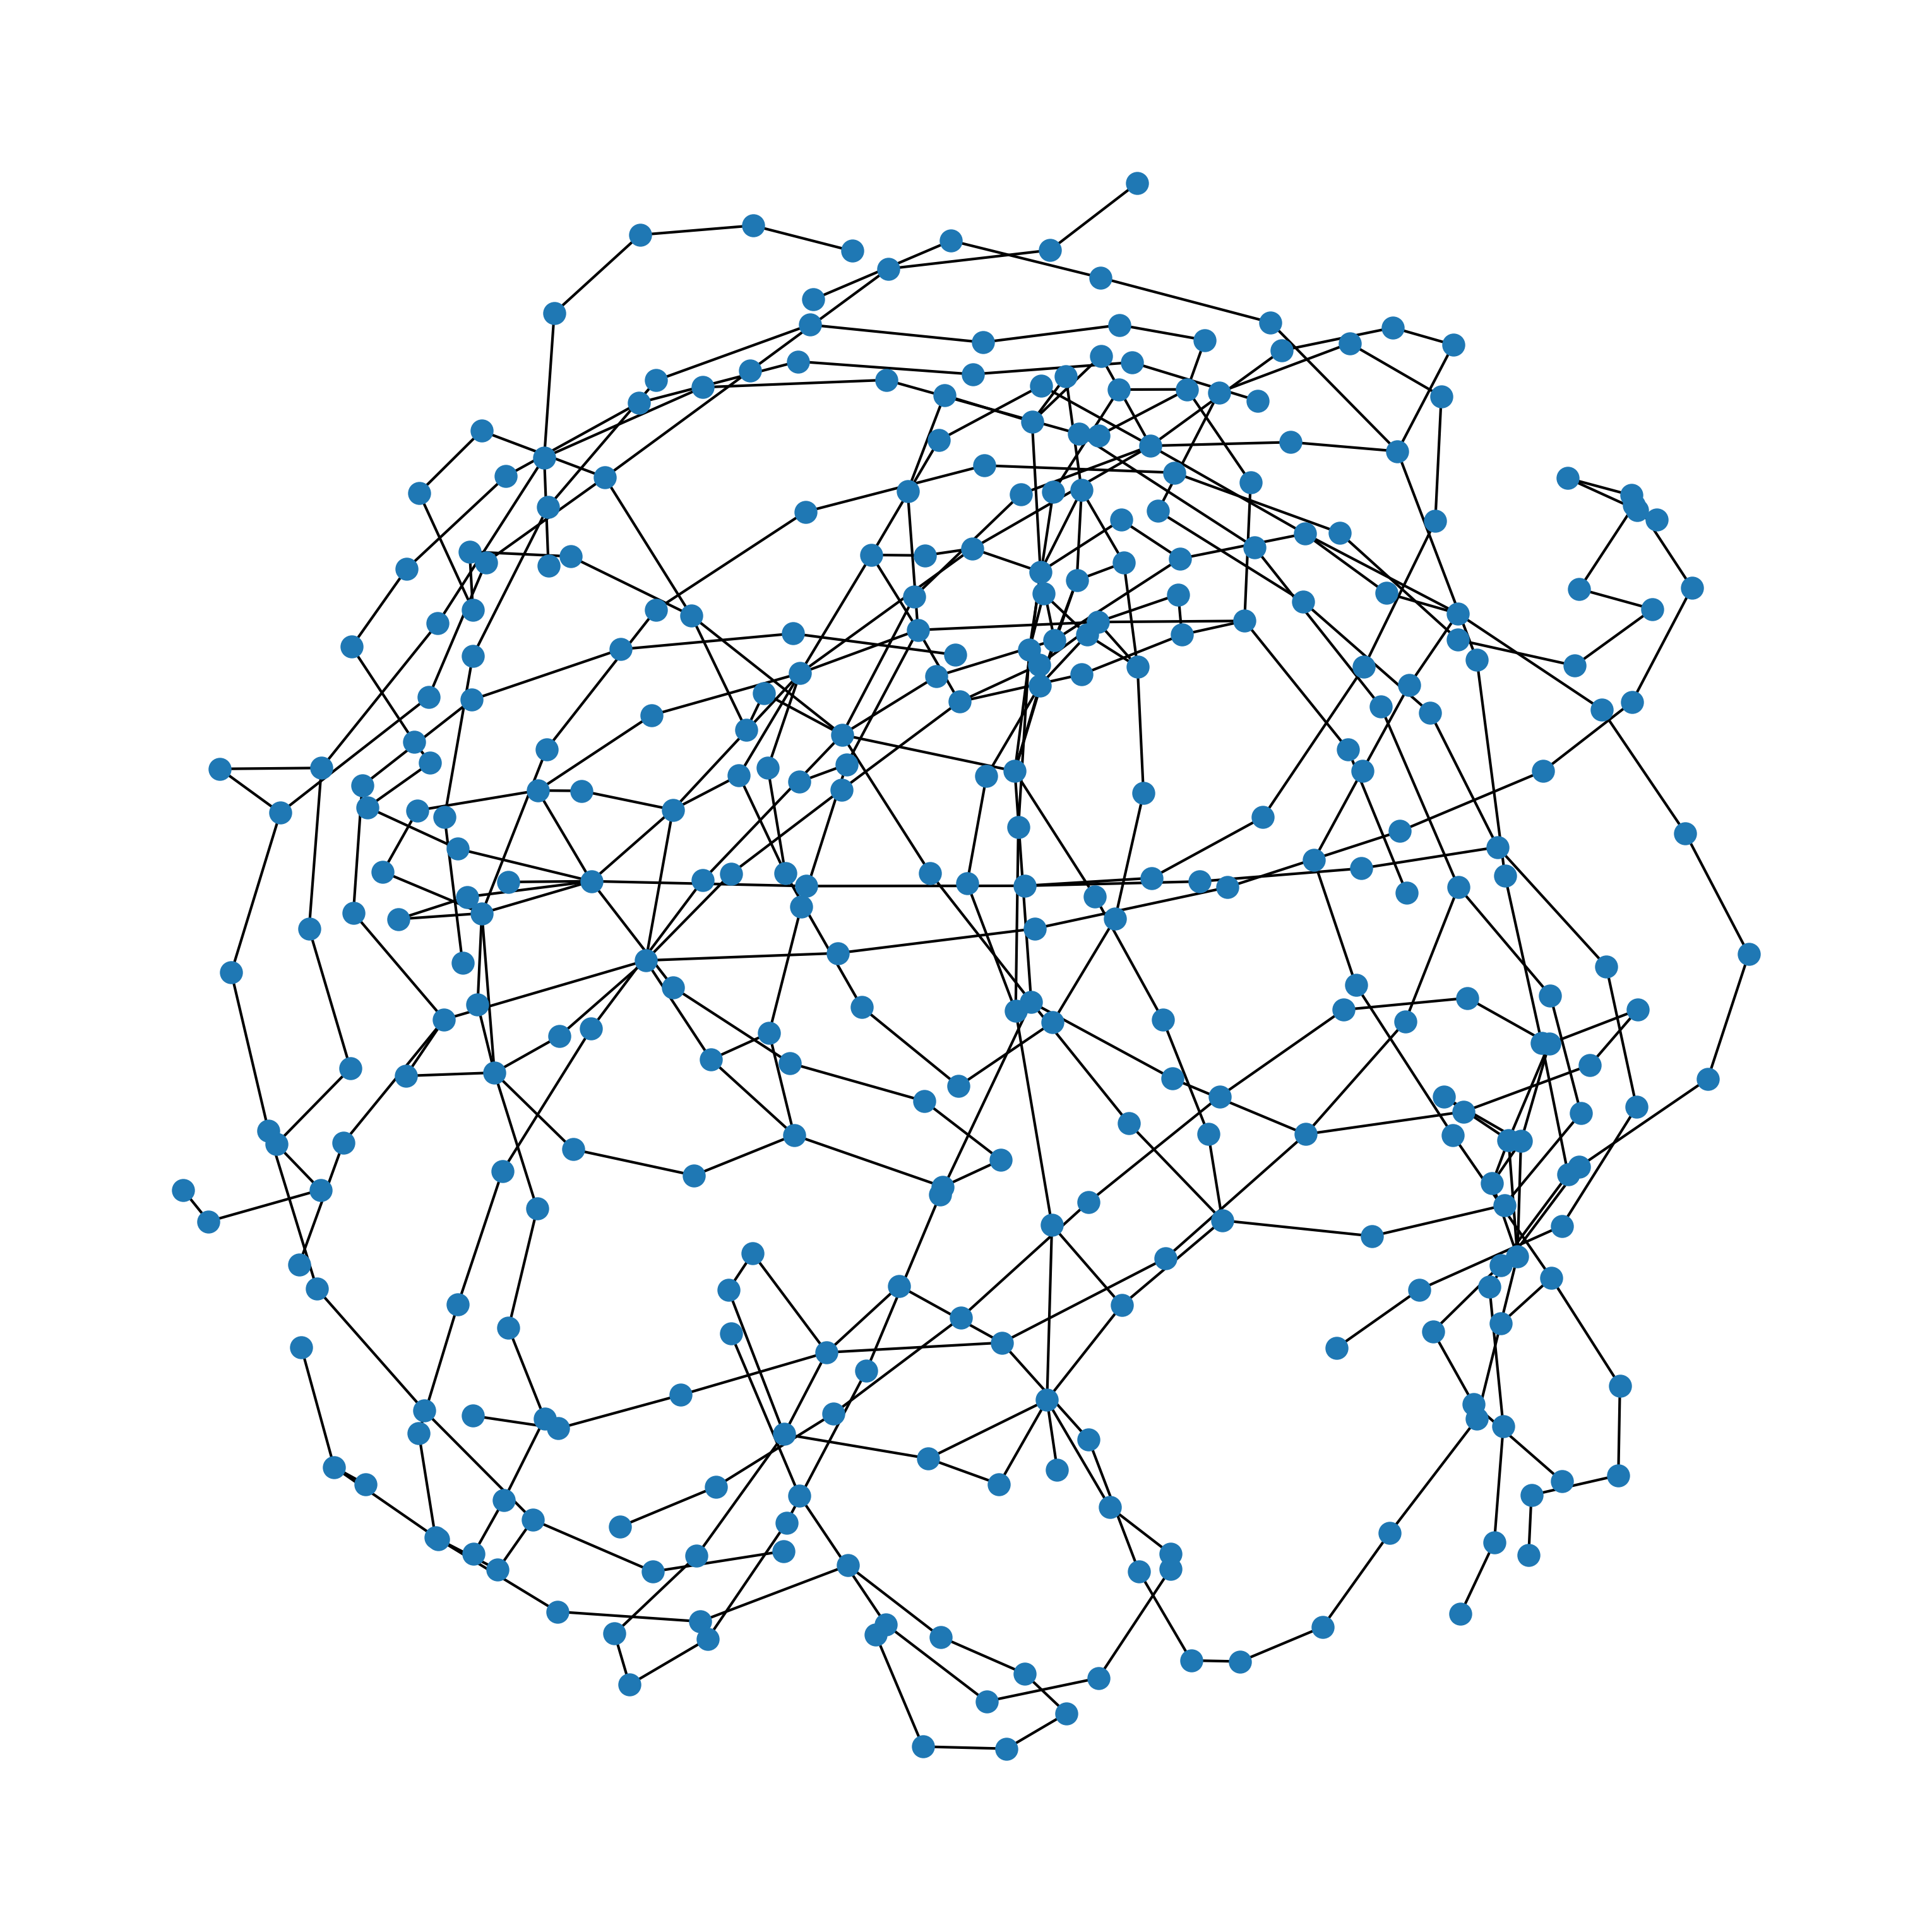

In [44]:
GTot=nx.read_adjlist(expanduser("~/Documents/Miktek Files/Betz Inaccesiblity Paper/London-Tube-Master-Dataset/london.connections_named.csv"),delimiter=',')
NT = len(GTot.nodes)
MT = len(GTot.edges) 

print(nx.diameter(GTot))

pos=nx.spring_layout(GTot,k=2, iterations=1000)
plt.figure(5,figsize=(10,10),dpi=300) 
nx.draw(GTot, pos,node_size=60,font_size=10)
plt.savefig('LondonTOTGraph.png', bbox_inches='tight', dpi=300)

In [45]:
Degnt = [val for (node, val) in GTot.degree()]

In [46]:
#Betweenness Centrality Calculation
Bent = nx.betweenness_centrality(GTot)
Bentarr=np.array(list(Bent.values()))

print("Top 10 Betweenness Centrality Nodes")
sorted(Bent.items(), reverse= True, key=lambda x: x[1])[:10]

Top 10 Betweenness Centrality Nodes


[('Bond Street', 0.45099795934743536),
 ('Liverpool Street', 0.42871665647143886),
 ('Farringdon', 0.4019118858573601),
 ('Whitechapel', 0.39744009633418426),
 ('Tottenham Court Road', 0.32269564101478254),
 ('Paddington', 0.2962739831882199),
 ('Stratford', 0.2898570406167182),
 ('Baker Street', 0.2882752132965356),
 ('Ealing Broadway', 0.20867548466695582),
 ('Finchley Road', 0.197916074389955)]

In [47]:
Cent = nx.closeness_centrality(GTot)
Centarr=np.array(list(Cent.values()))

print("Top 10 Closeness Centrality Nodes")
sorted(Cent.items(), reverse= True, key=lambda x: x[1])[:10]

Top 10 Closeness Centrality Nodes


[('Bond Street', 0.1307901907356948),
 ('Farringdon', 0.12972972972972974),
 ('Tottenham Court Road', 0.1295296838858905),
 ('Liverpool Street', 0.1266490765171504),
 ('Oxford Circus', 0.12551363466567053),
 ('Paddington', 0.12196007259528131),
 ('Baker Street', 0.12178325480246466),
 ('Green Park', 0.12151898734177215),
 ("King's Cross St. Pancras", 0.12129963898916968),
 ('Whitechapel', 0.12008577555396711)]

# Comparison Accessible versus Total Centralities

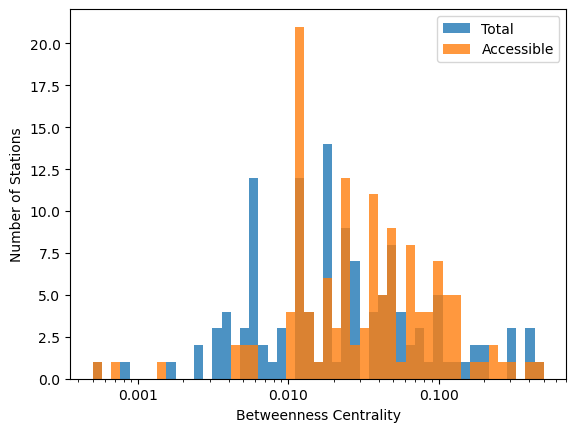

In [48]:
GTot = nx.relabel_nodes(GTot, {n: n.strip('\ufeff').strip() for n in GTot.nodes()})
GL = nx.relabel_nodes(GL, {n: n.strip('\ufeff').strip() for n in GL.nodes()})

bel_full = nx.betweenness_centrality(GTot)

BBB = np.array([bel_full.get(node, 0) for node in GL.nodes()])

MIN1, MAX1 = .0005, .5

fig, ax = plt.subplots()
plt.hist(BBB, bins = 10 ** np.linspace(np.log10(MIN1), np.log10(MAX1), 50),alpha=0.8)
plt.hist(Belarr, bins = 10 ** np.linspace(np.log10(MIN1), np.log10(MAX1), 50),alpha=.8)
pl.gca().set_xscale("log")
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.ticklabel_format(axis='x', style='plain')
plt.xlabel("Betweenness Centrality")
plt.ylabel("Number of Stations")
plt.legend(["Total", "Accessible"], fontsize=10)
plt.show()

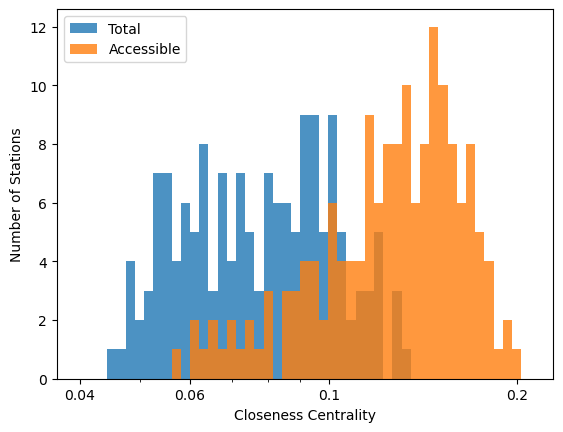

In [49]:
cel_full = nx.closeness_centrality(GTot)

CCC = np.array([cel_full.get(node, 0) for node in GL.nodes()])

MIN2, MAX2 = .04, .21

fig, ax = plt.subplots()
plt.hist(CCC, bins = 10 ** np.linspace(np.log10(MIN2), np.log10(MAX2), 50),alpha=0.8)
plt.hist(Celarr, bins = 10 ** np.linspace(np.log10(MIN2), np.log10(MAX2), 50),alpha=.8)
pl.gca().set_xscale("log")
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
plt.ticklabel_format(axis='x', style='plain')
plt.xticks([0.04,0.06,0.1,0.2],['0.04','0.06','0.1','0.2'])
plt.xlabel("Closeness Centrality")
plt.ylabel("Number of Stations")
plt.legend(["Total", "Accessible"], fontsize=10)
pl.show()

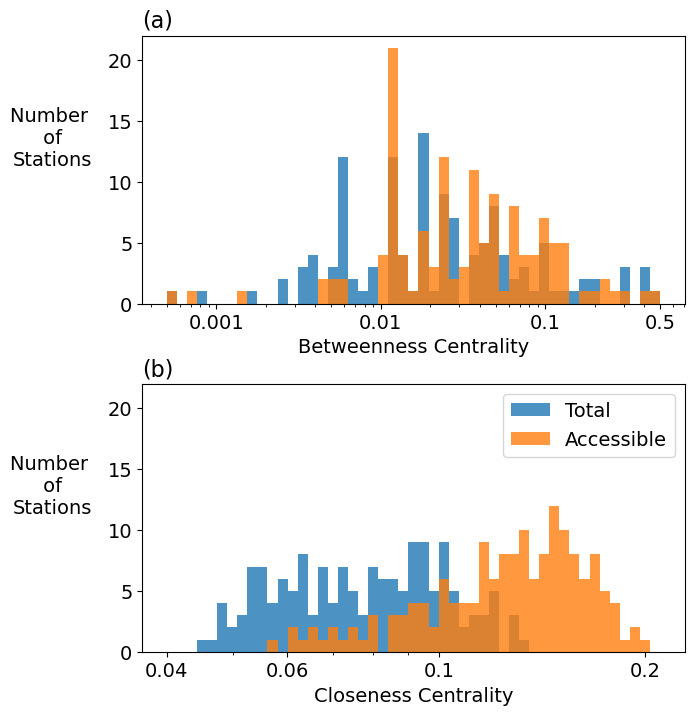

In [91]:
fig, ax = plt.subplots(2,1,figsize=(7,8))

ax[0].set_title('(a)',loc='left', fontsize=16)
ax[0].hist(BBB, bins = 10 ** np.linspace(np.log10(MIN1), np.log10(MAX1), 50),alpha=0.8)
ax[0].hist(Belarr, bins = 10 ** np.linspace(np.log10(MIN1), np.log10(MAX1), 50),alpha=.8)
ax[0].xaxis.set_major_formatter(ticker.ScalarFormatter())
ax[0].tick_params(axis='both', labelsize=14)
ax[0].set_xlabel("Betweenness Centrality", fontsize=14)
ax[0].set_ylabel("Number \n of \nStations", rotation=0, fontsize=14)
ax[0].set_xscale("log")
ax[0].yaxis.labelpad=40
ax[0].set_ylim(0,22)
ax[0].set_xticks([0.001,0.01,0.1,0.5])
ax[0].set_xticklabels(['0.001','0.01','0.1','0.5'])

ax[1].set_title('(b)',loc='left', fontsize=16)
ax[1].hist(CCC, bins = 10 ** np.linspace(np.log10(MIN2), np.log10(MAX2), 50),alpha=0.8)
ax[1].hist(Celarr, bins = 10 ** np.linspace(np.log10(MIN2), np.log10(MAX2), 50),alpha=.8)
ax[1].xaxis.set_major_formatter(ticker.ScalarFormatter())
ax[1].tick_params(axis='both', labelsize=14)
ax[1].set_xlabel("Closeness Centrality", fontsize=14)
ax[1].set_ylabel("Number \n of \nStations", rotation=0, fontsize=14)
ax[1].set_ylim(0,22)
ax[1].set_xscale("log")
ax[1].yaxis.labelpad=40
ax[1].set_xticks([0.04,0.06,0.1,0.2])
ax[1].set_xticklabels(['0.04','0.06','0.1','0.2'])
plt.legend(["Total", "Accessible"], fontsize=14)
plt.subplots_adjust(hspace=0.3)
plt.savefig('London_AVT.tiff', dpi=300)

# Comparison Degree versus Centrality Measures

''

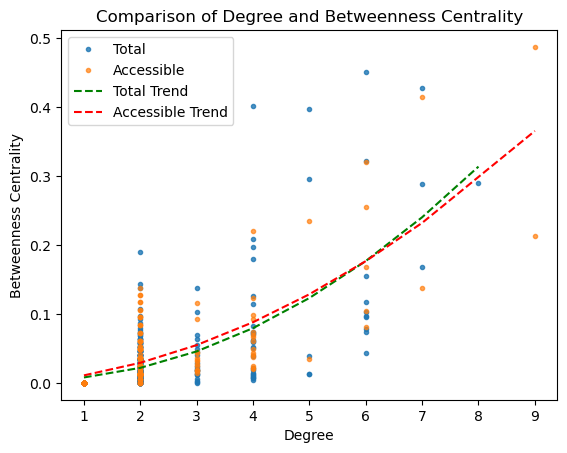

In [58]:
plt.plot(Degnt,Bentarr,'.', alpha=.8)

Degll=np.array(list(Degl))
Deglll=np.array(list(Degnt))
sorted_indicest = np.argsort(Deglll)
sorted_indices = np.argsort(Degll)
xt1_sorted = Deglll[sorted_indicest]
yt1_sorted = Bentarr[sorted_indicest]

zt1 = np.polyfit(xt1_sorted, yt1_sorted,2)
pt1 = np.poly1d(zt1)

plt.plot(Degl,Belarr,'.', alpha=.7)

xa1_sorted = Degll[sorted_indices]
ya1_sorted = Belarr[sorted_indices]

za1 = np.polyfit(xa1_sorted, ya1_sorted,2)
pa1 = np.poly1d(za1)
plt.plot(xt1_sorted, pt1(xt1_sorted), "g--")
plt.plot(xa1_sorted, pa1(xa1_sorted), "r--")

plt.legend(["Total","Accessible","Total Trend", "Accessible Trend"])
plt.xlabel('Degree')
plt.ylabel('Betweenness Centrality')
plt.title('Comparison of Degree and Betweenness Centrality')
;

''

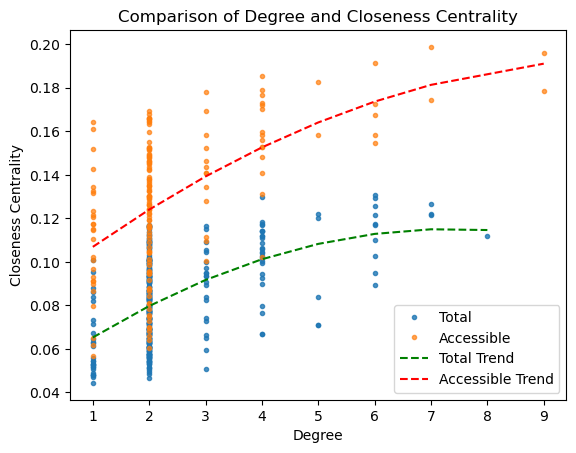

In [59]:
plt.plot(Degnt,Centarr,'.', alpha=0.8)

sorted_indices = np.argsort(Degll)
Deglll=np.array(list(Degnt))
sorted_indicest = np.argsort(Deglll)
xt2_sorted = Deglll[sorted_indicest]
yt2_sorted = Centarr[sorted_indicest]

zt2 = np.polyfit(xt2_sorted, yt2_sorted,2)
pt2 = np.poly1d(zt2)

plt.plot(Degl,Celarr,'.', alpha=0.7)

xa2_sorted = Degll[sorted_indices]
ya2_sorted = Celarr[sorted_indices]

za2 = np.polyfit(xa2_sorted, ya2_sorted,2)
pa2 = np.poly1d(za2)
plt.plot(xt2_sorted, pt2(xt2_sorted), "g--")
plt.plot(xa2_sorted, pa2(xa2_sorted), "r--")

plt.legend(["Total","Accessible","Total Trend", "Accessible Trend"])
plt.xlabel('Degree')
plt.ylabel('Closeness Centrality')
plt.title('Comparison of Degree and Closeness Centrality')
;

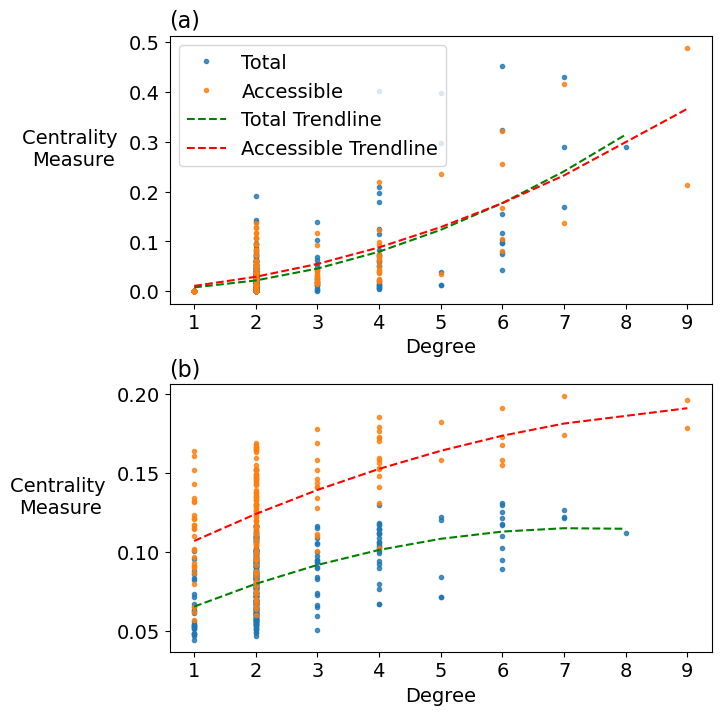

In [60]:
fig, ax = plt.subplots(2,1,figsize=(7,8))

ax[0].set_title('(a)',loc='left', fontsize=16)
ax[0].plot(Degnt,Bentarr,'.', alpha=.8)
ax[0].plot(Degl,Belarr,'.', alpha=.8)
ax[0].plot(xt1_sorted, pt1(xt1_sorted), "g--")
ax[0].plot(xa1_sorted, pa1(xa1_sorted), "r--")
ax[0].xaxis.set_major_formatter(ticker.ScalarFormatter())
ax[0].tick_params(axis='both', labelsize=14)
ax[0].yaxis.labelpad=40
ax[0].set_xlabel("Degree", fontsize=14)
ax[0].set_ylabel("Centrality \nMeasure", rotation=0, fontsize=14)
ax[0].legend(["Total", "Accessible", "Total Trendline", "Accessible Trendline"], fontsize=14)

ax[1].set_title('(b)',loc='left', fontsize=16)
ax[1].plot(Degnt,Centarr,'.', alpha=0.8)
ax[1].plot(Degl,Celarr,'.', alpha=0.8)
ax[1].plot(xt2_sorted, pt2(xt2_sorted), "g--")
ax[1].plot(xa2_sorted, pa2(xa2_sorted), "r--")
ax[1].xaxis.set_major_formatter(ticker.ScalarFormatter())
ax[1].yaxis.labelpad=40
ax[1].set_xlabel("Degree", fontsize=14)
ax[1].set_ylabel("Centrality \nMeasure", rotation=0, fontsize=14)
ax[1].tick_params(axis='both', labelsize=14)
plt.subplots_adjust(hspace=0.3)
plt.savefig('London_Cent_Comp.tiff', bbox_inches='tight', dpi=300)

# Power Law

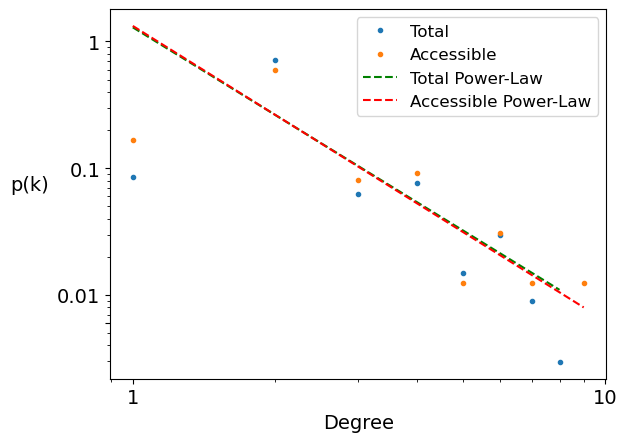

In [61]:
fig, ax = plt.subplots()

countst = Counter(d for n, d in GTot.degree())
histt = [countst.get(i, 0) for i in range(min(countst), max(countst) + 1)]
degree_sequencet = np.array(sorted([d for n, d in GTot.degree()], reverse=True))
degree_freqt = np.array(histt)/NT
degreest = range(1,len(degree_freqt)+1)
plt.loglog(degreest, degree_freqt,'.') 


countsl = Counter(d for n, d in GL.degree())
histl = [countsl.get(i, 0) for i in range(min(countsl), max(countsl) + 1)]
degree_sequencea = np.array(sorted([d for n, d in GL.degree()], reverse=True))
degree_freql = np.array(histl)/N
degreesl =range(1,len(degree_freql)+1)
plt.loglog(degreesl, degree_freql,'.') 

fitt = powerlaw.Fit(degree_sequencet, xmin=1)
fitt.power_law.plot_pdf(color='g', linestyle='--')
fita = powerlaw.Fit(degree_sequencea, xmin=1)
fita.power_law.plot_pdf(color='r', linestyle='--')

plt.xticks([1, 10],['1','10'])
plt.yticks([.006,.01,.1,1],[' ','0.01','0.1','1'])
ax.tick_params(axis='both', which='major', labelsize=14)
ax.yaxis.labelpad=20
plt.xlabel('Degree', fontsize=14)
plt.ylabel('p(k)', rotation=0, fontsize=14)
plt.legend(["Total","Accessible","Total Power-Law", "Accessible Power-Law"],fontsize=12)
plt.savefig('LondonPL.tiff', bbox_inches='tight', dpi=300)
plt.show()

In [62]:
print(fitt.power_law.alpha)
print(fita.power_law.alpha)

2.292484753410666
2.3269720898650945


# Income

In [63]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import urllib.request
import zipfile
import os

In [64]:
tfl_coords = pd.read_csv(r"C:\Users\pinkp\Documents\Miktek Files\Betz Inaccesiblity Paper\London-Tube-Master-Dataset\london.stations.csv")

stations_df = pd.DataFrame({"station": list(GL.nodes())})
stations_df = stations_df.merge(tfl_coords, left_on="station", right_on="name", how="left")

boroughs = gpd.read_file("https://github.com/radoi90/housequest-data/raw/master/london_boroughs.geojson").to_crs("EPSG:4326")

name_col = [c for c in boroughs.columns if c.lower() in ("name", "borough", "gss_name", "lad21nm")][0]

gdf = gpd.GeoDataFrame(
    stations_df.dropna(subset=["latitude", "longitude"]),
    geometry=[Point(lon, lat) for lon, lat in zip(stations_df.dropna(subset=["latitude","longitude"])["longitude"],
                                                   stations_df.dropna(subset=["latitude","longitude"])["latitude"])],
    crs="EPSG:4326"
)

stations_with_borough = gpd.sjoin(gdf, boroughs[["geometry", name_col]], how="left", predicate="within")
stations_with_borough.rename(columns={"name_right": "borough"}, inplace=True)
stations_with_borough = stations_with_borough.drop_duplicates(subset="station", keep="first")

In [65]:
income_df = pd.read_excel(r"C:\Users\pinkp\Documents\Miktek Files\Betz Inaccesiblity Paper\London Data\London_Income_Data.xlsx")

income_df = income_df.dropna(subset=["Borough"])
income_df = income_df[income_df["Code"].str.startswith("E090", na=False)]

# Remove commas and convert to numeric
income_df["MedianIncome"] = income_df["MedianIncome"].astype(str).str.replace(",", "").astype(float)

stations_with_income = stations_with_borough.merge(
    income_df, left_on="borough", right_on="Borough", how="left"
)

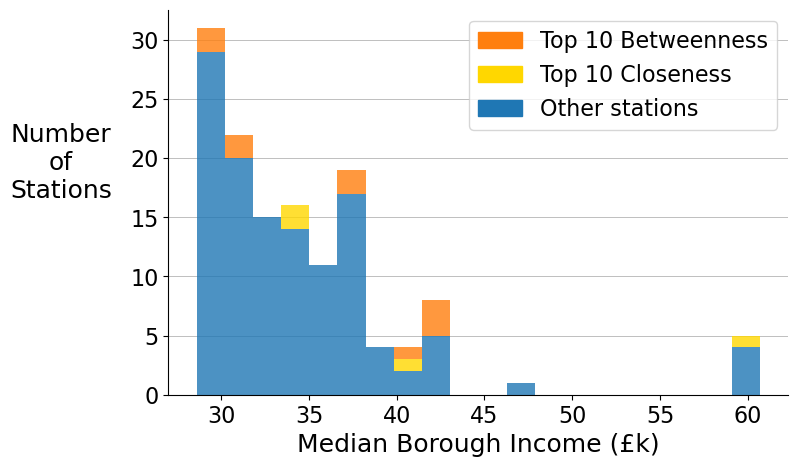

In [69]:
top10b=set([node for node, _ in sorted(Bel.items(), key=lambda x: x[1], reverse=True)[:10]])
top10c=set([node for node, _ in sorted(Cel.items(), key=lambda x: x[1], reverse=True)[:10]])
def get_color(station):
    if station in top10b:
        return "tab:orange"
    elif station in top10c:
        return "gold"
    else:
        return "tab:blue"

income_vals = stations_with_income["MedianIncome"].dropna()
stations_with_income["color"] = stations_with_income["station"].apply(get_color)
colors = stations_with_income.loc[stations_with_income["MedianIncome"].notna(), "color"]
_, bin_edges = np.histogram(income_vals, bins=20)

# Sort so blue at bottom, gold middle, orange on top
color_order = {"tab:blue": 0, "gold": 1, "tab:orange": 2}
plot_data = sorted(zip(income_vals, colors), key=lambda x: color_order.get(x[1], 0))

bin_bottoms = {}

fig, ax = plt.subplots(figsize=(8,5))
ax.yaxis.grid(True, color="grey", linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)

for income, color in plot_data:
    bin_idx = np.digitize(income, bin_edges[:-1]) - 1
    bin_idx = min(bin_idx, len(bin_edges) - 2)
    bottom = bin_bottoms.get(bin_idx, 0)
    width = bin_edges[bin_idx + 1] - bin_edges[bin_idx]
    ax.bar(bin_edges[bin_idx], 1, width=width, bottom=bottom,
           color=color, alpha=0.8, edgecolor="none", align="edge")
    bin_bottoms[bin_idx] = bottom + 1

legend_handles = [
    Patch(color="tab:orange", label="Top 10 Betweenness"),
    Patch(color="gold",       label="Top 10 Closeness"),
    Patch(color="tab:blue",   label="Other stations"),
]
ax.legend(handles=legend_handles, fontsize=16)
ax.set_xlabel("Median Borough Income (£k)", fontsize=18)
ax.set_ylabel("Number\nof\nStations", fontsize=18, labelpad=50, rotation=0)
ax.tick_params(axis='both', labelsize=16)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.savefig("Fig5.tiff", dpi=300)
plt.show()

# Tourism

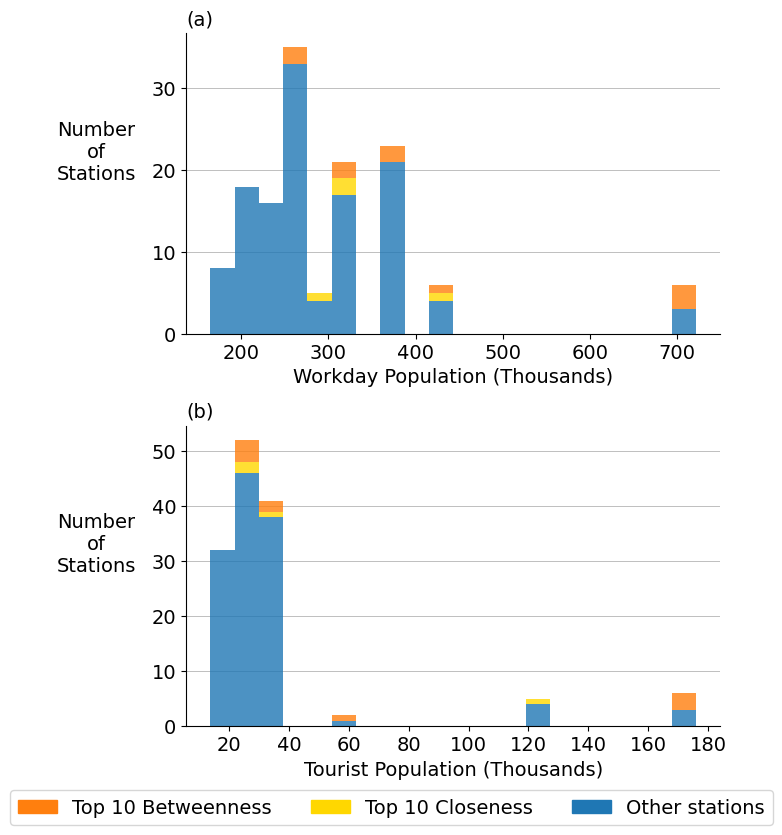

In [90]:
pop_df = pd.read_csv(r"C:\Users\pinkp\Documents\Miktek Files\Betz Inaccesiblity Paper\London Data\London_Population_Data.csv")
pop_df = pop_df.dropna(subset=["Boroughs"])
pop_df = pop_df[pop_df["Code"].str.startswith("E090", na=False)]

# Remove commas and convert to numeric
pop_df["Workday Population"] = pop_df["Workday Population"].astype(str).str.replace(",", "").astype(float)
pop_df["Tourist Population"] = pop_df["Tourist Population"].astype(str).str.replace(",", "").astype(float)

# Merge with stations
stations_with_pop = stations_with_borough.merge(
    pop_df, left_on="borough", right_on="Boroughs", how="left"
)
stations_with_pop["color"] = stations_with_pop["station"].apply(get_color)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7,8))

for i, (ax, col, title) in enumerate([
    (ax1, "Workday Population", "Workday Population"),
    (ax2, "Tourist Population", "Tourist Population")
]):
    pop_vals = stations_with_pop[col].dropna()
    colors = stations_with_pop.loc[stations_with_pop[col].notna(), "color"]

    _, bin_edges = np.histogram(pop_vals, bins=20)

    color_order = {"tab:blue": 0, "gold": 1, "tab:orange": 2}
    plot_data = sorted(zip(pop_vals, colors), key=lambda x: color_order.get(x[1], 0))

    bin_bottoms = {}

    ax.yaxis.grid(True, color="grey", linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)

    for pop, color in plot_data:
        bin_idx = np.digitize(pop, bin_edges[:-1]) - 1
        bin_idx = min(bin_idx, len(bin_edges) - 2)
        bottom = bin_bottoms.get(bin_idx, 0)
        width = bin_edges[bin_idx + 1] - bin_edges[bin_idx]
        ax.bar(bin_edges[bin_idx], 1, width=width, bottom=bottom,
               color=color, alpha=0.8, edgecolor="none", align="edge")
        bin_bottoms[bin_idx] = bottom + 1

    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x/1000)}"))
    ax.set_title(f"({string.ascii_lowercase[i]})", loc="left", fontsize=14)
    ax.set_xlabel(f"{title} (Thousands)", fontsize=14)
    ax.set_ylabel("Number\nof\nStations", rotation= 0, labelpad=40,fontsize=14)
    ax.tick_params(axis='both', labelsize=14)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

legend_handles = [
    Patch(color="tab:orange", label="Top 10 Betweenness"),
    Patch(color="gold",       label="Top 10 Closeness"),
    Patch(color="tab:blue",   label="Other stations"),
]
fig.legend(handles=legend_handles, fontsize=14, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig("Fig6.tiff", dpi=300)
plt.show()